#                                                           Advanced EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import autocorrelation_plot
import scipy.stats as stats


### Load and Preprocess the Data

In [2]:
df = pd.read_csv("depi_grouped_main.csv", parse_dates=['Created at'])

df.head()

,Name,Created at,Subtotal,Shipping,Total,Discount Amount,Shipping Method,Shipping Province,Shipping Province Name,Payment Method,...,month,day_of_week,year,year_month,season,holiday_name,is_holiday,is_weekend,day_type,item_count
0,#MC14035,2022-11-01 00:32:29+02:00,1150.0,0.0,1150.0,95.0,Free Shipping,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,18
1,#MC14036,2022-11-01 04:58:48+02:00,620.0,50.0,670.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,3
2,#MC14037,2022-11-01 07:49:44+02:00,440.0,50.0,490.0,0.0,Shipping Rate,GZ,Giza,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,1
3,#MC14038,2022-11-01 08:08:38+02:00,600.0,50.0,650.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,1
4,#MC14039,2022-11-01 08:21:14+02:00,408.0,50.0,458.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),...,11,Tuesday,2022,2022-11,Fall,NaN,False,False,Weekday,6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24856 entries, 0 to 24855
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype                    
---  ------                     --------------  -----                    
 0   Name                       24856 non-null  object                   
 1   Created at                 24856 non-null  datetime64[ns, UTC+02:00]
 2   Subtotal                   24856 non-null  float64                  
 3   Shipping                   24856 non-null  float64                  
 4   Total                      24856 non-null  float64                  
 5   Discount Amount            24856 non-null  float64                  
 6   Shipping Method            24856 non-null  object                   
 7   Shipping Province          24856 non-null  object                   
 8   Shipping Province Name     24856 non-null  object                   
 9   Payment Method             24856 non-null  object                   
 10

In [8]:
# df_daily = df.groupby('Created at').agg({
#     'Total': 'sum',
#     'item_count': 'sum'
# }).reset_index()


# date_range = pd.date_range(start=df_daily['Created at'].min(), end=df_daily['Created at'].max(), freq='D')

# df_daily = pd.merge(pd.DataFrame({'Created at': date_range}), df_daily, on='Created at', how='left')

# df_daily.fillna(method='ffill', inplace=True)

# df_daily.set_index('Created at', inplace=True)


df_daily = pd.read_csv("daily_sales_data.csv")

### Visualizing the Time Series and identifying trends

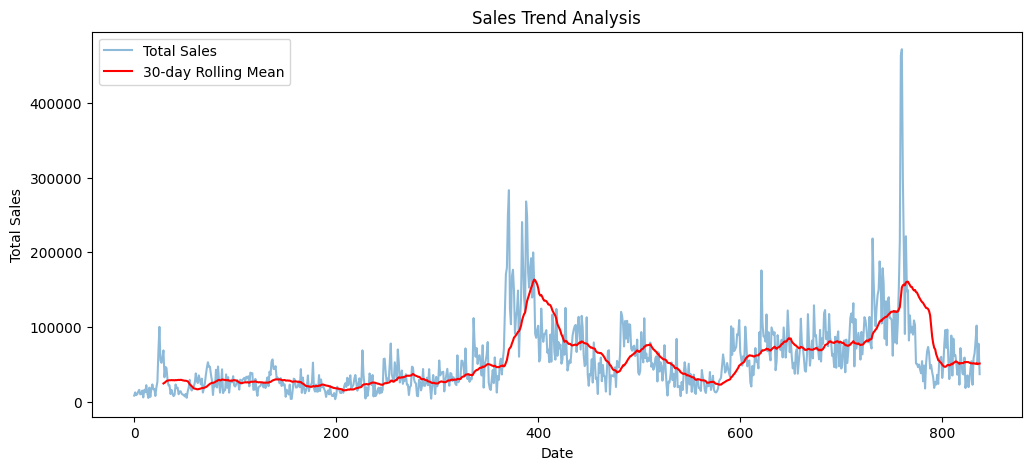

In [10]:
# df_daily['Rolling_Mean'] = df_daily['Total'].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_daily['Total'], label="Total Sales", alpha=0.5)
plt.plot(df_daily['total_30d_avg'], label="30-day Rolling Mean", color='red')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Trend Analysis")
plt.legend()
plt.show()


### Detecting Seasonality

<Axes: title={'center': 'Seasonal Component'}, xlabel='Created at'>

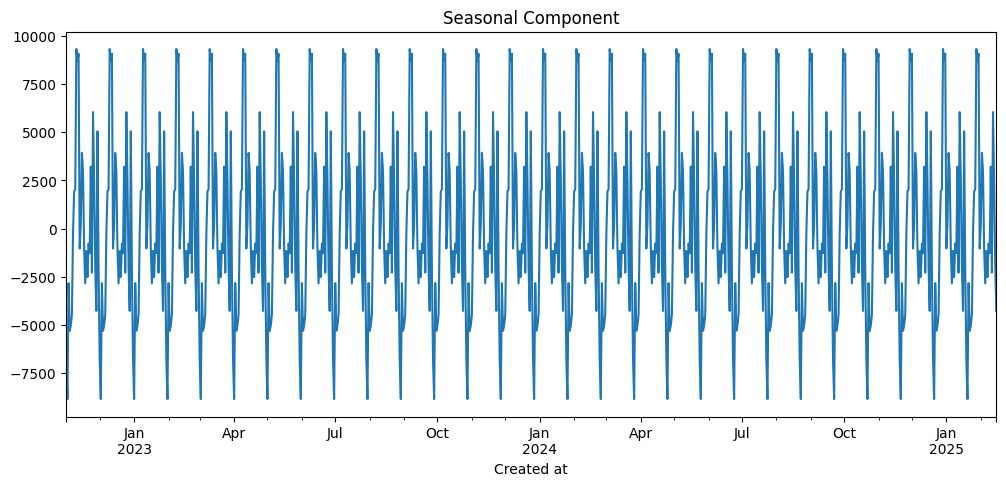

In [9]:
decomposition = seasonal_decompose(df_daily['Total'], model='additive', period=30)
decomposition.seasonal.plot(title="Seasonal Component", figsize=(12, 5))


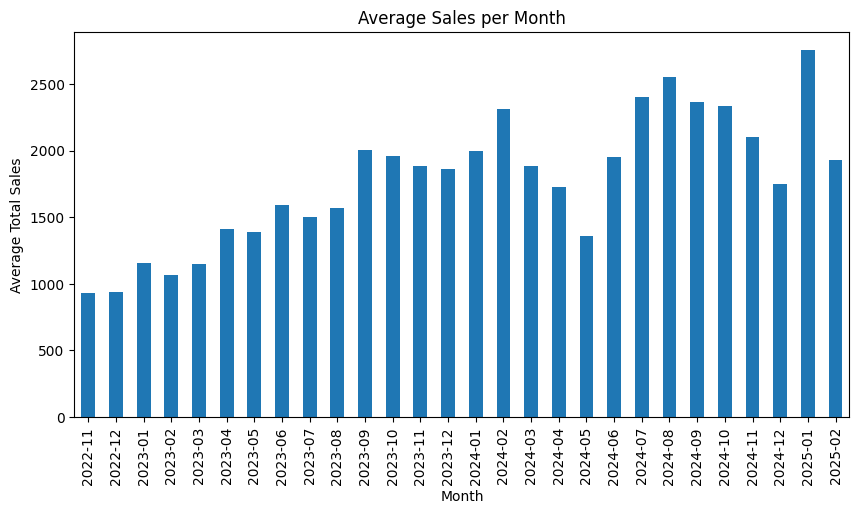

In [ ]:
df_monthly = df.groupby('year_month')['Total'].mean()

df_monthly.plot(kind='bar', figsize=(10, 5), title="Average Sales per Month")
plt.xlabel("Month")
plt.ylabel("Average Total Sales")
plt.show()


### Detecting Cyclic Patterns

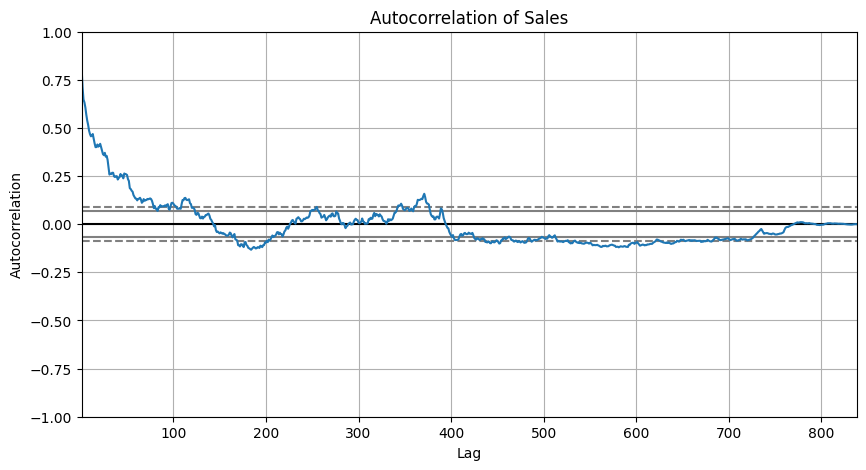

In [15]:
plt.figure(figsize=(10, 5))
autocorrelation_plot(df_daily['Total'])
plt.title("Autocorrelation of Sales")
plt.show()


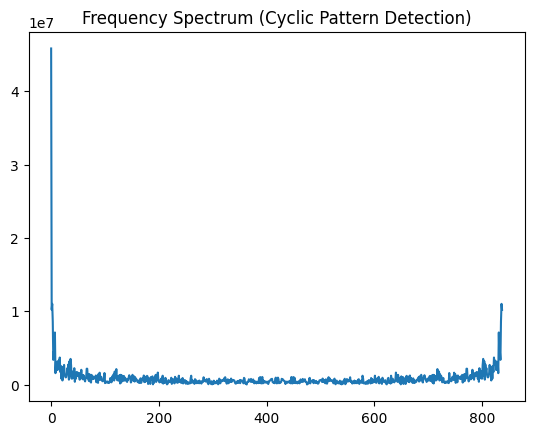

In [16]:
freq_spectrum = np.fft.fft(df_daily['Total'].dropna())
plt.plot(np.abs(freq_spectrum))
plt.title("Frequency Spectrum (Cyclic Pattern Detection)")
plt.show()


### Checking for Stationarity

In [17]:
result = adfuller(df_daily['Total'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] < 0.05:
    print("The series is stationary (no trend).")
else:
    print("The series is non-stationary (trend present).")


ADF Statistic: -5.043686897997726
p-value: 1.81740943990513e-05
The series is stationary (no trend).


### Extras

In [18]:
df['is_holiday'] = df['is_holiday'].astype(int)
df['is_weekend'] = df['is_weekend'].astype(int)
df['season'] = df['season'].astype('category').cat.codes
df['day_of_week'] = df['day_of_week'].astype('category').cat.codes

numeric_cols = ['Total', 'Discount Amount', 'Refunded Amount', 'is_holiday',
                'is_weekend', 'item_count', 'season', 'day_of_week']

df_corr = df[numeric_cols]


In [19]:
corr_matrix = df_corr.corr(method='pearson')
print(corr_matrix)


                    Total  Discount Amount  Refunded Amount  is_holiday  \
Total            1.000000         0.352583         0.092005   -0.003448   
Discount Amount  0.352583         1.000000         0.012199   -0.014003   
Refunded Amount  0.092005         0.012199         1.000000   -0.005191   
is_holiday      -0.003448        -0.014003        -0.005191    1.000000   
is_weekend       0.003489        -0.010210         0.002143   -0.038121   
item_count       0.565015         0.466848         0.042086   -0.006301   
season           0.004896         0.005451        -0.013922    0.045613   
day_of_week     -0.004928         0.006716        -0.008282    0.005324   

                 is_weekend  item_count    season  day_of_week  
Total              0.003489    0.565015  0.004896    -0.004928  
Discount Amount   -0.010210    0.466848  0.005451     0.006716  
Refunded Amount    0.002143    0.042086 -0.013922    -0.008282  
is_holiday        -0.038121   -0.006301  0.045613     0.005324  

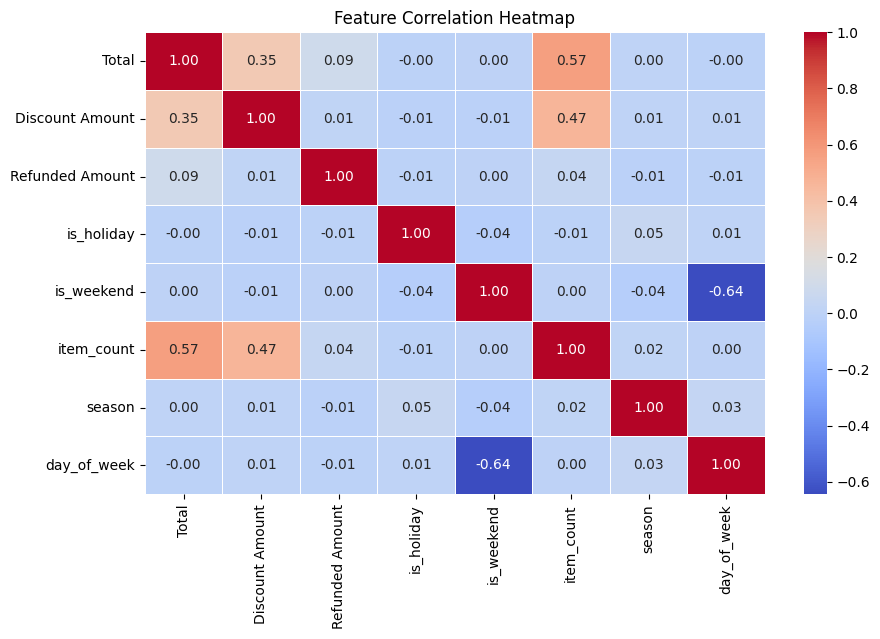

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


/var/folders/rd/rm1ghq0950j6l712s6ykcc5w0000gn/T/ipykernel_76120/3227513424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['season'], y=df['Total'], palette="coolwarm")


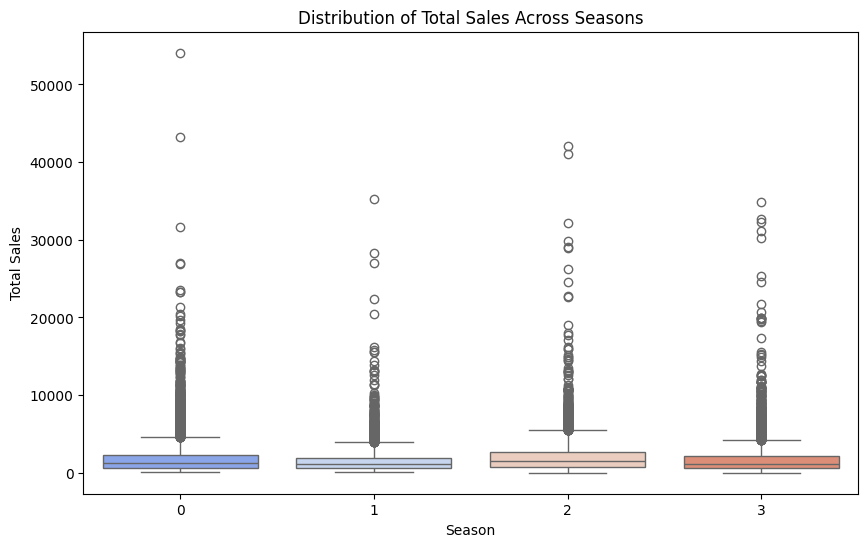

In [21]:
df['season'] = df['season'].astype('category')
plt.figure(figsize=(10,6))
sns.boxplot(x=df['season'], y=df['Total'], palette="coolwarm")
plt.title("Distribution of Total Sales Across Seasons")
plt.xlabel("Season")
plt.ylabel("Total Sales")
plt.show()


In [23]:
season_groups = [group['Total'].values for _, group in df.groupby('season',observed=False)]

f_stat, p_value = stats.f_oneway(*season_groups)

print(f"ANOVA F-statistic: {f_stat}")
print(f"P-value: {p_value}")
if p_value < 0.05:
    print("There is a significant difference in Total Sales across seasons.")
else:
    print("No significant difference in Total Sales across seasons.")


ANOVA F-statistic: 44.994678693828426
P-value: 5.457639638876034e-29
There is a significant difference in Total Sales across seasons.


In [24]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_results = pairwise_tukeyhsd(df['Total'], df['season'])

print(tukey_results)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     0      1 -204.3789    0.0 -312.0869  -96.671   True
     0      2  305.8626    0.0  209.5543 402.1709   True
     0      3  -84.8565 0.0614 -172.3868   2.6738  False
     1      2  510.2415    0.0  386.1818 634.3013   True
     1      3  119.5225 0.0441    2.1466 236.8983   True
     2      3 -390.7191    0.0 -497.7302 -283.708   True
--------------------------------------------------------


In [25]:
# Retrieve the original category order
category_mapping = dict(enumerate(df['season'].astype('category').cat.categories))
print(category_mapping)  # This shows which number corresponds to each season


{0: 0, 1: 1, 2: 2, 3: 3}


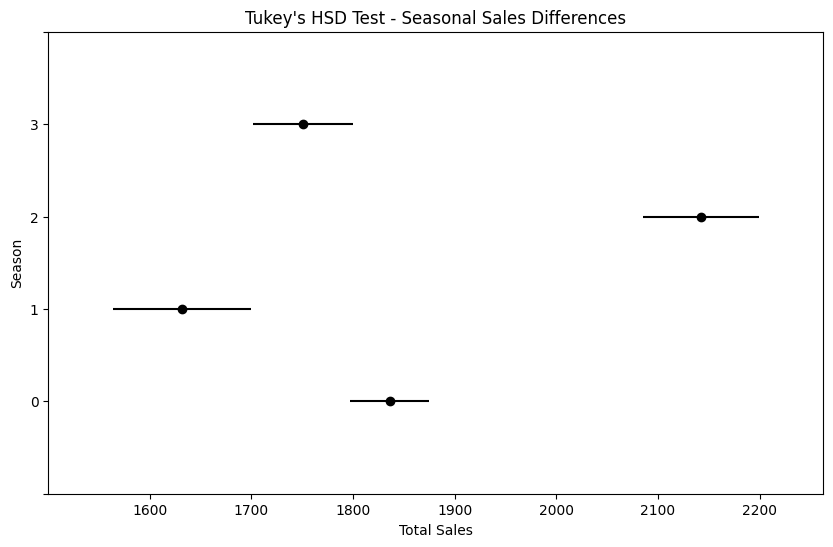

In [26]:
df['season'] = df['season'].map(category_mapping)
tukey_results.plot_simultaneous()
plt.xlabel("Total Sales")
plt.ylabel("Season")
plt.title("Tukey's HSD Test - Seasonal Sales Differences")
plt.show()

<Axes: xlabel='Total', ylabel='Density'>

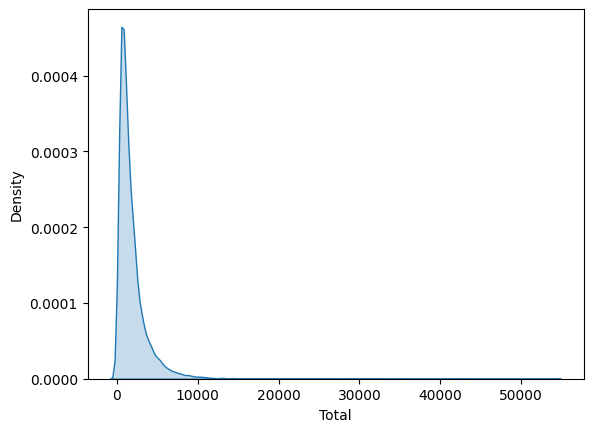

In [27]:
sns.kdeplot(df["Total"], fill=True)


#  Interactive Time Series Plot for dyanmaic Expolration

In [28]:
import plotly.express as px
fig = px.line(df, x="Created at", y="Total", title="Interactive Time Series Analysis")
fig.show()


/Users/ziadghanem/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning:

urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020



In [29]:
df['year'] = df['Created at'].dt.year
df['month'] = df['Created at'].dt.month
df['week_of_year'] = df['Created at'].dt.isocalendar().week
df['day_of_week'] = df['Created at'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

print(df.head())


       Name                Created at  Subtotal  Shipping   Total  \
0  #MC14035 2022-11-01 00:32:29+02:00    1150.0       0.0  1150.0   
1  #MC14036 2022-11-01 04:58:48+02:00     620.0      50.0   670.0   
2  #MC14037 2022-11-01 07:49:44+02:00     440.0      50.0   490.0   
3  #MC14038 2022-11-01 08:08:38+02:00     600.0      50.0   650.0   
4  #MC14039 2022-11-01 08:21:14+02:00     408.0      50.0   458.0   

   Discount Amount Shipping Method Shipping Province Shipping Province Name  \
0             95.0   Free Shipping                 C                  Cairo   
1              0.0   Shipping Rate                 C                  Cairo   
2              0.0   Shipping Rate                GZ                   Giza   
3              0.0   Shipping Rate                 C                  Cairo   
4              0.0   Shipping Rate                 C                  Cairo   

           Payment Method  ... day_of_week  year year_month season  \
0  Cash on Delivery (COD)  ...          

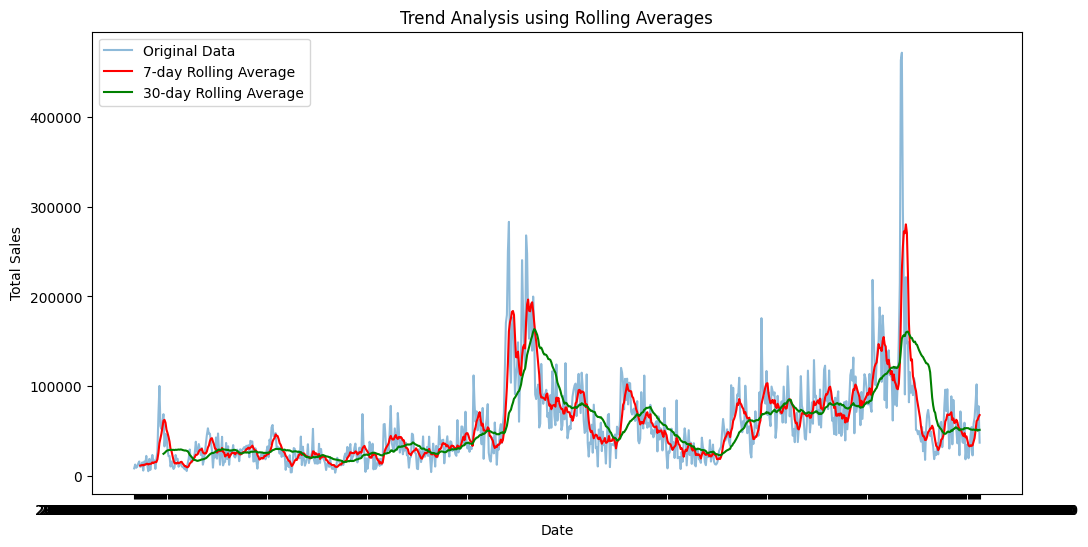

In [33]:
# df['rolling_7'] = df['Total'].rolling(window=7).mean()
# df['rolling_30'] = df['Total'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df_daily['Created at'], df_daily['Total'], label="Original Data", alpha=0.5)
plt.plot(df_daily['Created at'], df_daily['total_7d_avg'], label="7-day Rolling Average", color='red')
plt.plot(df_daily['Created at'], df_daily['total_30d_avg'], label="30-day Rolling Average", color='green')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Trend Analysis using Rolling Averages")
plt.legend()
plt.show()


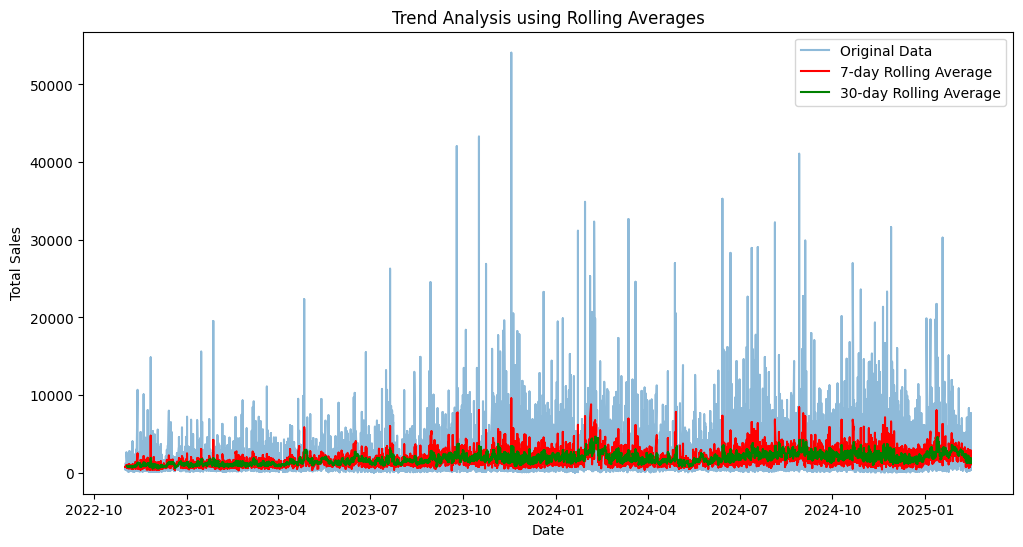

In [ ]:
df['rolling_7'] = df['Total'].rolling(window=7).mean()
df['rolling_30'] = df['Total'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Created at'], df['Total'], label="Original Data", alpha=0.5)
plt.plot(df['Created at'], df['rolling_7'], label="7-day Rolling Average", color='red')
plt.plot(df['Created at'], df['rolling_30'], label="30-day Rolling Average", color='green')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Trend Analysis using Rolling Averages")
plt.legend()
plt.show()


# Clustering Data Using K-Means

<ipython-input-40-d7a2ca156ba8>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



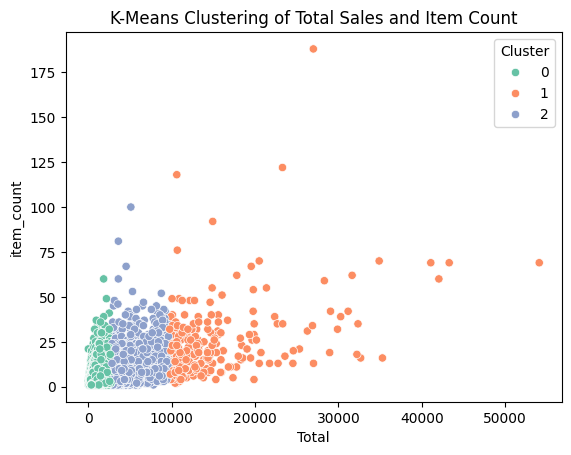

In [40]:
from sklearn.cluster import KMeans


df_cluster = df[['Total', 'item_count']]
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(df_cluster)
sns.scatterplot(x=df_cluster['Total'], y=df_cluster['item_count'], hue=df_cluster['Cluster'], palette="Set2")
plt.title("K-Means Clustering of Total Sales and Item Count")
plt.show()
